<a href="https://colab.research.google.com/github/Kaiking28/ECON3916-Statistical-Machine-Learning/blob/main/Assignment%203/Econ_3916_Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

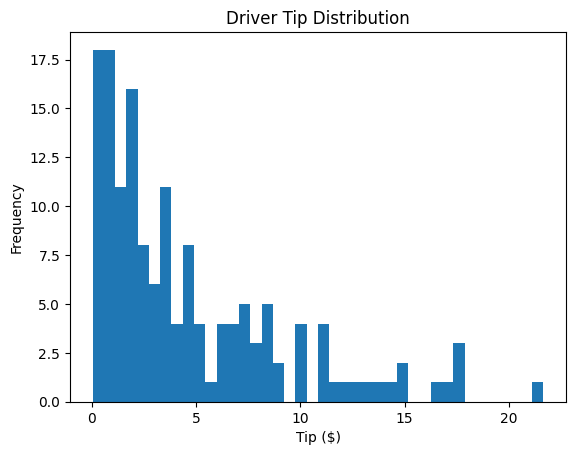

In [2]:
np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

plt.hist(driver_tips[driver_tips > 0], bins=40)
plt.title('Driver Tip Distribution')
plt.xlabel('Tip ($)')
plt.ylabel('Frequency')
plt.show()

Observed Median: $0.7553
95% CI: ($0.2643, $1.3636)
Lower distance: $0.4911
Upper distance: $0.6082


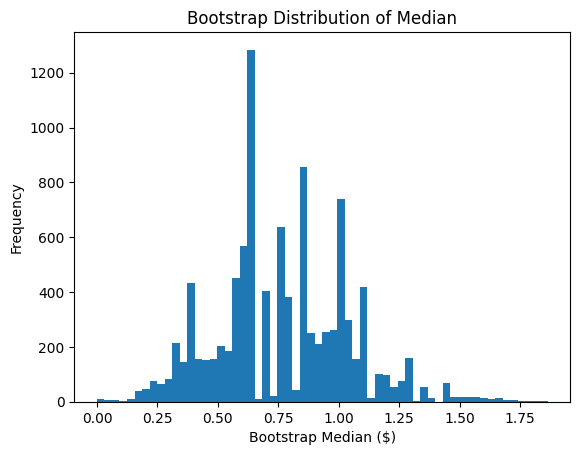

In [8]:
np.random.seed(42)
N_BOOT = 10000
n = len(driver_tips)
boot_medians = np.empty(N_BOOT)

for i in range(N_BOOT):
    resample = driver_tips[np.random.randint(0, n, size=n)]
    boot_medians[i] = np.median(resample)

ci_lower = np.percentile(boot_medians, 2.5)
ci_upper = np.percentile(boot_medians, 97.5)
observed_median = np.median(driver_tips)

print(f'Observed Median: ${observed_median:.4f}')
print(f'95% CI: (${ci_lower:.4f}, ${ci_upper:.4f})')
print(f'Lower distance: ${observed_median - ci_lower:.4f}')
print(f'Upper distance: ${ci_upper - observed_median:.4f}')

plt.hist(boot_medians, bins=60)
plt.title('Bootstrap Distribution of Median')
plt.xlabel('Bootstrap Median ($)')
plt.ylabel('Frequency')
plt.show()

Control mean: 35.03, std: 4.90
Treatment mean: 32.77, std: 13.35
Observed difference (C - T): 2.2650


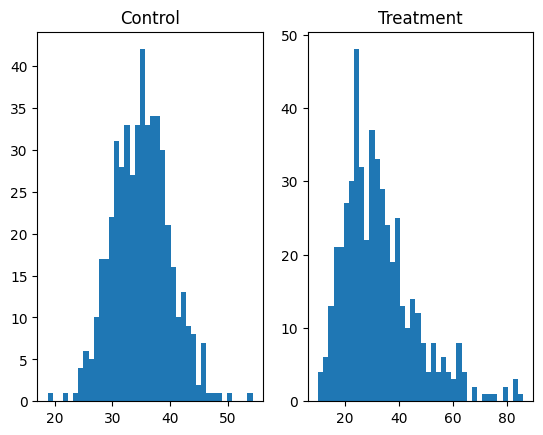

In [9]:
np.random.seed(42)
N = 500

control = np.random.normal(loc=35, scale=5, size=N)
treatment = np.random.lognormal(mean=3.4, sigma=0.4, size=N)
obs_diff = control.mean() - treatment.mean()

print(f'Control mean: {control.mean():.2f}, std: {control.std():.2f}')
print(f'Treatment mean: {treatment.mean():.2f}, std: {treatment.std():.2f}')
print(f'Observed difference (C - T): {obs_diff:.4f}')

fig, axes = plt.subplots(1, 2)
axes[0].hist(control, bins=40)
axes[0].set_title('Control')
axes[1].hist(treatment, bins=40)
axes[1].set_title('Treatment')
plt.show()

Observed difference: 2.2650
Empirical p-value: 0.0004
Reject H0


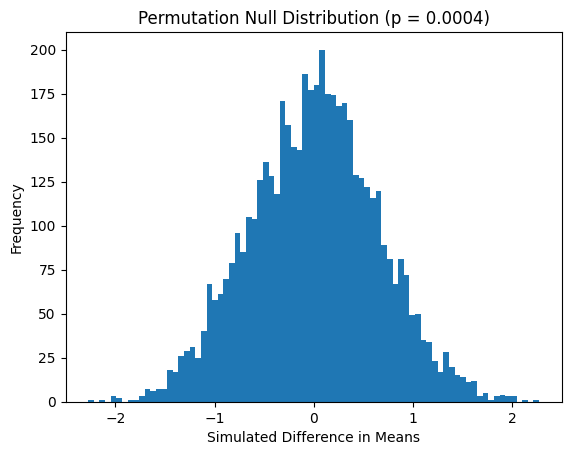

In [10]:
np.random.seed(42)
N_PERM = 5000
combined = np.concatenate([control, treatment])
perm_diffs = np.empty(N_PERM)

for i in range(N_PERM):
    shuffled = np.random.permutation(combined)
    perm_diffs[i] = shuffled[:N].mean() - shuffled[N:].mean()

p_value = np.mean(np.abs(perm_diffs) >= np.abs(obs_diff))

print(f'Observed difference: {obs_diff:.4f}')
print(f'Empirical p-value: {p_value:.4f}')
print('Reject H0' if p_value < 0.05 else 'Fail to reject H0')

plt.hist(perm_diffs, bins=80)
plt.title(f'Permutation Null Distribution (p = {p_value:.4f})')
plt.xlabel('Simulated Difference in Means')
plt.ylabel('Frequency')
plt.show()

In [11]:
df = pd.read_csv('swiftcart_loyalty.csv')
print(df.head())
print(df.groupby('subscriber')[['pre_spend','account_age','support_tickets','post_spend']].mean().round(2))

mean_sub = df.loc[df['subscriber'] == 1, 'post_spend'].mean()
mean_nonsub = df.loc[df['subscriber'] == 0, 'post_spend'].mean()
naive_sdo = mean_sub - mean_nonsub

print(f'Subscriber mean: ${mean_sub:.2f}')
print(f'Non-subscriber mean: ${mean_nonsub:.2f}')
print(f'Naive SDO: ${naive_sdo:.2f}')

   subscriber  pre_spend  account_age  support_tickets  post_spend
0           1  57.450712           37                2   85.169648
1           1  47.926035           41                0   72.802404
2           1  59.715328           41                0   79.858905
3           1  72.845448           34                0   80.335466
4           1  46.487699           34                2   67.956227
            pre_spend  account_age  support_tickets  post_spend
subscriber                                                     
0               45.43        27.28             1.08       56.47
1               55.09        32.76             0.91       74.04
Subscriber mean: $74.04
Non-subscriber mean: $56.47
Naive SDO: $17.57


In [12]:
COVARIATES = ['pre_spend', 'account_age', 'support_tickets']

X = StandardScaler().fit_transform(df[COVARIATES])
D = df['subscriber'].values

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X, D)
df['propensity_score'] = lr.predict_proba(X)[:, 1]

treated = df[df.subscriber == 1].reset_index(drop=True)
control_pool = df[df.subscriber == 0].reset_index(drop=True)

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control_pool[['propensity_score']])
_, indices = nn.kneighbors(treated[['propensity_score']])
matched_control = control_pool.iloc[indices.flatten()].reset_index(drop=True)

att = (treated['post_spend'].values - matched_control['post_spend'].values).mean()

print(f'Naive SDO: ${naive_sdo:.2f}')
print(f'PSM ATT:   ${att:.2f}')
print(f'Bias removed: ${naive_sdo - att:.2f}')

Naive SDO: $17.57
PSM ATT:   $10.02
Bias removed: $7.55


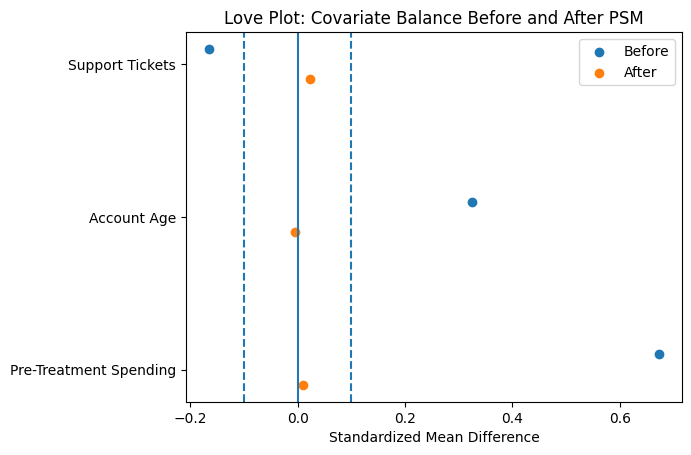

In [13]:
def compute_smd(t_df, c_df, features):
    smds = {}
    for f in features:
        pooled_sd = np.sqrt((t_df[f].var() + c_df[f].var()) / 2)
        smds[f] = (t_df[f].mean() - c_df[f].mean()) / pooled_sd
    return smds

smd_before = compute_smd(df[df.subscriber==1][COVARIATES], df[df.subscriber==0][COVARIATES], COVARIATES)
smd_after  = compute_smd(treated[COVARIATES], matched_control[COVARIATES], COVARIATES)

labels = ['Pre-Treatment Spending', 'Account Age', 'Support Tickets']
smd_b = list(smd_before.values())
smd_a = list(smd_after.values())
y_pos = np.arange(len(COVARIATES))

plt.scatter(smd_b, y_pos + 0.1, label='Before')
plt.scatter(smd_a, y_pos - 0.1, label='After')
plt.yticks(y_pos, labels)
plt.axvline(x=0)
plt.axvline(x=0.1, linestyle='--')
plt.axvline(x=-0.1, linestyle='--')
plt.xlabel('Standardized Mean Difference')
plt.title('Love Plot: Covariate Balance Before and After PSM')
plt.legend()
plt.show()